In [1]:
%load_ext autoreload
%autoreload 2

In [22]:
from pathlib import Path
import string
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.lines as mlines

from phd_project.config.config import load_config
from phd_project.plotting import custom_log_formatter
from phd_project.scripts.WP1_ground_motion_set.hazard_curves import (
    group_hazard_curves)

from phd_project.scripts.oqhelpers import (
    get_probability,
    get_disagg_from_datastore
    )

from openquake.commonlib.datastore import read

cfg = load_config()

In [3]:
# TODO:: 
# Prior to running the analyses in this note book the dissagregation analyses
# for the chosen sites need to be run.
# Make sure you have run the PSHA / Dissaggregation defined by the following
# file:

# print(cfg["hazard_models"]["eshm20_AvgSA_sel_sites"])
 

In [4]:
# load the site model and the sites
sel_sites = pd.read_csv(cfg["results"]["selected_sites_csv"])
site_model = pd.read_csv(cfg["hazard_models"]["eshm20_AvgSA_site_model_all"])
site_metadata = pd.concat([sel_sites, site_model], axis=1).T.drop_duplicates().T
site_metadata.columns

Index(['index', 'region', 'seismicity', 'AvgSA', 'nearest_town', 'country',
       'lat', 'lon', 'vs30', 'vs30measured', 'xvf', 'z1pt0', 'z2pt5'],
      dtype='object')

# Plotting Constants

In [ ]:
legend_font_params = {'size': 9}
legend_title_font_params = {'weight': 'bold', 'size': 9}

# hazard curve plots
hc_labels = ["High site", "Low/mod site", "Mean - high sites", "Mean - low/mod sites"]
hc_colours = ["r", "g", "r", "g"]
hc_line_styles = ["-", "-", "--", "--"]
hc_alphas = [0.3, 0.3, 1.0, 1.0]

# hc comparison
hc_com_labels = ["AvgSA[0,3] - High", "Low/mod", "Mean - high sites", "Mean - low/mod sites"]
hc_com_colours = ["r", "g", "r", "g"]
hc_com_line_styles = ["-", "-", "--", "--"]

# PSHA Results

## AvgSA[0,3]

In [47]:
calc_id = 14
dstore = read(calc_id)

In [48]:
# group the hazard curves by seismicity and region
groups = list(site_metadata.groupby(["seismicity", "region"]).size().index)
grouped_hcs_03 = group_hazard_curves(groups, site_metadata, dstore)

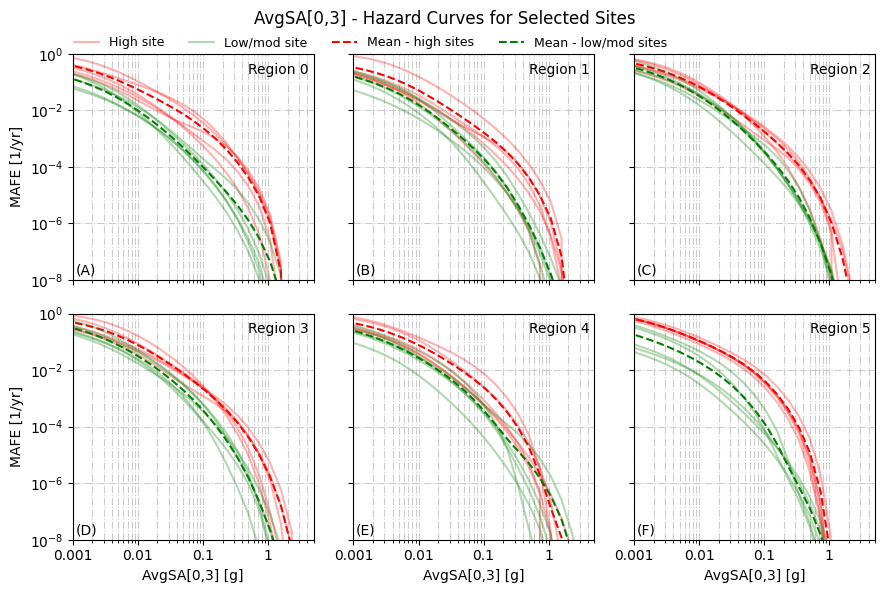

In [49]:
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(9, 6))

regions = list(range(0,6))
seismicities = ("high", "lowmod")

for ii, (r, ax) in enumerate(zip(regions, axs.flatten())):
    for s in seismicities:
        color = "r" if s == "high" else "g"

        for id, hcs in grouped_hcs_03[(s, r)].items():
            hc = hcs["AvgSA"]["mean"]
            if id == "mean_site":
                ax.loglog(hc[:,0], hc[:,1], ls="--", color=color, label=id)
            else:
                ax.loglog(hc[:,0], hc[:,1], ls="-", color=color, alpha=0.3, label=id)

    formatter = ticker.FuncFormatter(custom_log_formatter)
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim(0.001, 5)
    ax.set_ylim(1e-8, 1)

    ax.grid(True, which="both", ls="-.", color="0.8")
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', left=False)
    
    ax.text(0.0011, 1.5e-8, f"({string.ascii_uppercase[ii]})")
    ax.text(0.5, 2e-1, f"Region {r}")

axs[0,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_xlabel("AvgSA[0,3] [g]")
axs[1,1].set_xlabel("AvgSA[0,3] [g]")
axs[1,2].set_xlabel("AvgSA[0,3] [g]")

handles = [
    mlines.Line2D([], [], color=c, label=l, linestyle=ls, alpha=a) 
    for c, l, ls, a in zip(hc_colours, hc_labels, hc_line_styles, hc_alphas)
]

# loc="center left" tells matplotlib which part of the legend box to anchor
# bbox_to_anchor=(1, 0.5) moves that anchor point to the far right (1) and middle height (0.5)
leg = fig.legend(handles=handles,
                 ncols=4, 
                 loc="upper left", 
                 bbox_to_anchor=(0.075, 0.955), 
                #  title="Legend:",
                #  title_fontproperties=legend_title_font_params,
                 prop=legend_font_params,
                 frameon=False)
leg._legend_box.align = "left"

fig.suptitle("AvgSA[0,3] - Hazard Curves for Selected Sites")
fig.tight_layout()

## AvgSA[0,6]

In [50]:
calc_id = 20
dstore = read(calc_id)

In [51]:
# group the hazard curves by seismicity and region
groups = list(site_metadata.groupby(["seismicity", "region"]).size().index)
grouped_hcs_06 = group_hazard_curves(groups, site_metadata, dstore)

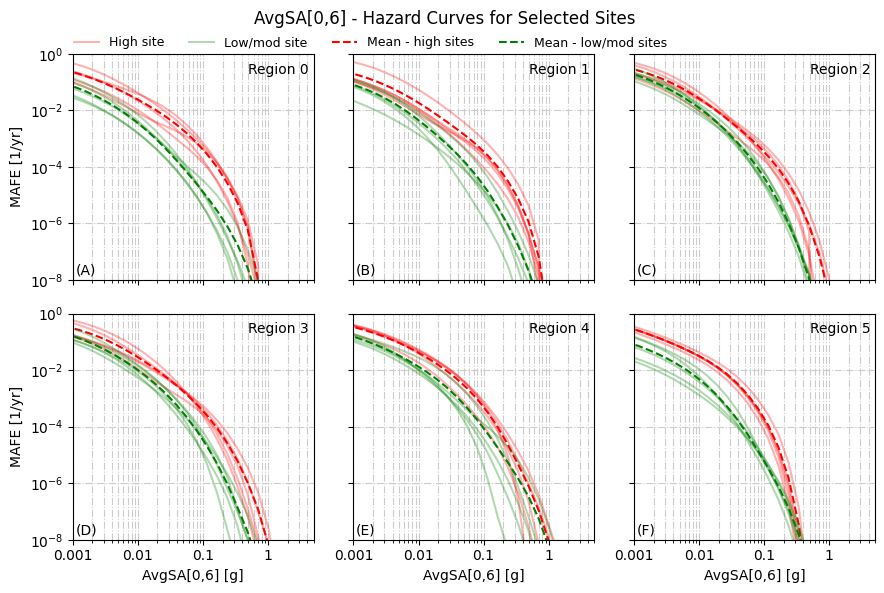

In [52]:
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(9, 6))

regions = list(range(0,6))
seismicities = ("high", "lowmod")

for ii, (r, ax) in enumerate(zip(regions, axs.flatten())):
    for s in seismicities:
        color = "r" if s == "high" else "g"

        for id, hcs in grouped_hcs_06[(s, r)].items():
            hc = hcs["AvgSA"]["mean"]
            if id == "mean_site":
                ax.loglog(hc[:,0], hc[:,1], ls="--", color=color, label=id)
            else:
                ax.loglog(hc[:,0], hc[:,1], ls="-", color=color, alpha=0.3, label=id)

    formatter = ticker.FuncFormatter(custom_log_formatter)
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim(0.001, 5)
    ax.set_ylim(1e-8, 1)

    ax.grid(True, which="both", ls="-.", color="0.8")
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', left=False)
    
    ax.text(0.0011, 1.5e-8, f"({string.ascii_uppercase[ii]})")
    ax.text(0.5, 2e-1, f"Region {r}")

axs[0,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_xlabel("AvgSA[0,6] [g]")
axs[1,1].set_xlabel("AvgSA[0,6] [g]")
axs[1,2].set_xlabel("AvgSA[0,6] [g]")

handles = [
    mlines.Line2D([], [], color=c, label=l, linestyle=ls, alpha=a) 
    for c, l, ls, a in zip(hc_colours, hc_labels, hc_line_styles, hc_alphas)
]

# loc="center left" tells matplotlib which part of the legend box to anchor
# bbox_to_anchor=(1, 0.5) moves that anchor point to the far right (1) and middle height (0.5)
leg = fig.legend(handles=handles,
                 ncols=4, 
                 loc="upper left", 
                 bbox_to_anchor=(0.075, 0.955), 
                #  title="Legend:",
                #  title_fontproperties=legend_title_font_params,
                 prop=legend_font_params,
                 frameon=False)
leg._legend_box.align = "left"

fig.suptitle("AvgSA[0,6] - Hazard Curves for Selected Sites")
fig.tight_layout()

## Comparison

In [55]:
grouped_hcs_06[('high', 0)].keys()


dict_keys([30, 31, 32, 33, 34, 'mean_site'])

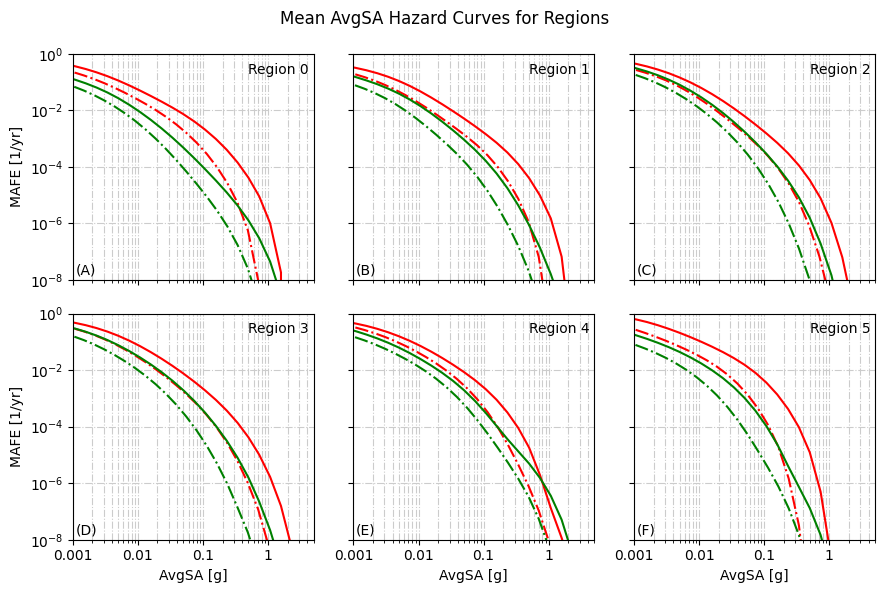

In [57]:
fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(9, 6))

regions = list(range(0,6))
seismicities = ("high", "lowmod")

for ii, (r, ax) in enumerate(zip(regions, axs.flatten())):
    for s in seismicities:
        color = "r" if s == "high" else "g"

        hc_06 = grouped_hcs_06[(s,r)]["mean_site"]["AvgSA"]["mean"]
        hc_03 = grouped_hcs_03[(s,r)]["mean_site"]["AvgSA"]["mean"]

        ax.loglog(hc_03[:,0], hc_03[:,1], ls="-", color=color, label=id)
        ax.loglog(hc_06[:,0], hc_06[:,1], ls="-.", color=color, label=id)


    formatter = ticker.FuncFormatter(custom_log_formatter)
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlim(0.001, 5)
    ax.set_ylim(1e-8, 1)

    ax.grid(True, which="both", ls="-.", color="0.8")
    ax.minorticks_on()
    ax.tick_params(axis='y', which='minor', left=False)
    
    ax.text(0.0011, 1.5e-8, f"({string.ascii_uppercase[ii]})")
    ax.text(0.5, 2e-1, f"Region {r}")

axs[0,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_ylabel("MAFE [1/yr]")
axs[1,0].set_xlabel("AvgSA [g]")
axs[1,1].set_xlabel("AvgSA [g]")
axs[1,2].set_xlabel("AvgSA [g]")

# handles = [
#     mlines.Line2D([], [], color=c, label=l, linestyle=ls, alpha=a) 
#     for c, l, ls, a in zip(hc_colours, hc_labels, hc_line_styles, hc_alphas)
# ]

# loc="center left" tells matplotlib which part of the legend box to anchor
# bbox_to_anchor=(1, 0.5) moves that anchor point to the far right (1) and middle height (0.5)
# leg = fig.legend(handles=handles,
#                  ncols=4, 
#                  loc="upper left", 
#                  bbox_to_anchor=(0.075, 0.955), 
#                 #  title="Legend:",
#                 #  title_fontproperties=legend_title_font_params,
#                  prop=legend_font_params,
#                  frameon=False)
# leg._legend_box.align = "left"

fig.suptitle("Mean AvgSA Hazard Curves for Regions")
fig.tight_layout()

# Disaggregation

## AvgSA[0,3]

In [9]:
calc_id = 16
dstore = read(calc_id)
disagg_type = 'TRT_Mag_Dist_Eps'

In [10]:
list(dstore["disagg-bins"])

['Dist', 'Eps', 'Lat', 'Lon', 'Mag', 'TRT']

In [11]:
print(dstore["disagg-stats"]['TRT_Mag_Dist_Eps'].shape)
dstore["disagg-stats"]['TRT_Mag_Dist_Eps'].attrs["shape_descr"]

(60, 6, 10, 25, 6, 1, 5, 1)


array(['site_id', 'TRT', 'Mag', 'Dist', 'Eps', 'imt', 'poe', 'Z'],
      dtype=object)

In [12]:
list(dstore["oqparam"])

[('all_cost_types', []),
 ('area_source_discretization', 10.0),
 ('base_path',
  'C:\\Users\\clemettn\\Documents\\phd\\hazard_models\\eshm20\\regional_avgSA'),
 ('calculation_mode', 'disaggregation'),
 ('complex_fault_mesh_spacing', 50.0),
 ('coordinate_bin_width', 5.0),
 ('description', '[ESHM20 main region AvgSA 0 to 3 - all sites]'),
 ('disagg_outputs', ['TRT_Mag_Dist_Eps']),
 ('distance_bin_width', 20.0),
 ('export_dir',
  'C:\\Users\\clemettn\\Documents\\phd\\hazard_models\\eshm20\\regional_avgSA'),
 ('exports', ['']),
 ('hazard_imtls',
  {'AvgSA': [0.0005,
    0.0007338996338110349,
    0.001077217345015942,
    0.0015811388300841897,
    0.00232079441680639,
    0.003406460345289808,
    0.005000000000000001,
    0.007338996338110349,
    0.010772173450159421,
    0.015811388300841903,
    0.023207944168063915,
    0.034064603452898065,
    0.050000000000000024,
    0.07338996338110354,
    0.10772173450159424,
    0.15811388300841914,
    0.2320794416806391,
    0.3406460345289

In [20]:
dstore["disagg-bins/TRT"][0].decode("UTF-8")

'Craton'

In [21]:
get_probability(dstore, disagg_type, 
                site_idx=0, 
                imt_bin="AvgSA", 
                poe_bin=2.01e-4, 
                trt_bin="Shallow Default", 
                mag_bin=7.75, 
                dist_bin=150, 
                eps_bin=2.5)

array([2.4008481e-07])

In [39]:
site_disaggs = get_disagg_from_datastore(dstore, disagg_type)

(0, slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), 0, 0, slice(None, None, None))
(0, slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), 0, 1, slice(None, None, None))
(0, slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), 0, 2, slice(None, None, None))
(0, slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), 0, 3, slice(None, None, None))
(0, slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), 0, 4, slice(None, None, None))
(1, slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), 0, 0, slice(None, None, None))
(1, slice(None, None, None), slice(None, None, None), slice(None, None, None), slice(None, None, None), 0, 1, slice(None, None, None))
(1, slice(None, None, None), slice(None, None, None), s

In [35]:
idx = (0, slice(None), slice(None), slice(None), slice(None), 0, 0, slice(None))
dstore["disagg-stats"]["TRT_Mag_Dist_Eps"][idx]

array([[[[[0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00]],

         [[0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00]],

         [[0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00]],

         ...,

         [[0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00]],

         [[0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00]],

         [[0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+

In [ ]:
print(dstore["disagg-stats"]["TRT_Mag_Dist_Eps"])
print(type(dstore["disagg-stats"]["TRT_Mag_Dist_Eps"].attrs["shape_descr"][0]))

<HDF5 dataset "TRT_Mag_Dist_Eps": shape (60, 6, 10, 25, 6, 1, 5, 1), type "<f8">
<class 'str'>


In [ ]:
dstore["hmaps-stats"].attrs["json"]

'{\n"shape_descr": ["site_id", "stat", "imt", "poe"],\n"site_id": 60,\n"stat": ["mean"],\n"imt": ["AvgSA"],\n"poe": [0.02, 0.002103, 0.000667, 0.000404, 0.000201]}'

In [ ]:
dstore["hcurves-stats"].attrs["json"]



'{\n"shape_descr": ["site_id", "stat", "imt", "lvl"],\n"site_id": 60,\n"stat": ["mean"],\n"imt": ["AvgSA"],\n"lvl": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]}'

In [ ]:
dstore["oqparam"].hazard_imtls

{'AvgSA': [0.0005,
  0.0007338996338110349,
  0.001077217345015942,
  0.0015811388300841897,
  0.00232079441680639,
  0.003406460345289808,
  0.005000000000000001,
  0.007338996338110349,
  0.010772173450159421,
  0.015811388300841903,
  0.023207944168063915,
  0.034064603452898065,
  0.050000000000000024,
  0.07338996338110354,
  0.10772173450159424,
  0.15811388300841914,
  0.2320794416806391,
  0.3406460345289807,
  0.5000000000000003,
  0.733899633811035,
  1.0772173450159437,
  1.5811388300841902,
  2.320794416806389,
  3.406460345289811,
  5.000000000000004]}